# IAC 2026 — Week 2b: **LOCKED FINAL TEST**

**Paper:** *Hybrid AI-Augmented Framework for High-Fidelity Tracking of Non-Cooperative Objects*  
**Paper ID:** IAC-26,A6,9,8,x109530

This notebook contains **no training and no model tuning**.

It loads the exact frozen Week-2a model, scalers, object split, and physical configuration; verifies them with SHA-256 hashes; accesses the six held-out TEST Starlink objects and calendar year 2025 for the first time; and produces the final paper evaluation.

## Predeclared final-test design

- **6 held-out TEST Starlink objects**
- **2025 real historical space weather only**
- 2 objectively selected quiet days
- 2 objectively selected moderate days
- 2 objectively selected storm days
- 3 frozen observation regimes:
  - 10-minute nominal
  - 20-minute nominal
  - 10-minute cadence with a 4-hour blackout (10–14 h)

Expected population: **6 × 6 × 3 = 108 scenarios**.

Methods:
- SGP4
- frozen tuned EKF
- frozen EKF + GRU

Primary paired inference is performed at the **object × weather-day** level so the three correlated observation schedules are not treated as independent trajectories.

> After this final test is viewed, do not alter the model, Q, features, weather selection, or seeds and rerun for a better result.

In [ ]:
!pip -q install "sgp4>=2.25" "pymsis>=0.12.0" "astropy>=6.0" scikit-learn joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.1/218.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.8 MB/s eta 0:00:00


In [ ]:
import json, math, shutil, zipfile, hashlib, warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import t as student_t, ttest_1samp, wilcoxon
from sgp4.api import Satrec, SGP4_ERRORS
from sgp4 import omm

import pymsis
from pymsis.utils import download_f107_ap, get_f107_ap

import astropy.units as u
from astropy.time import Time, TimeDelta
from astropy.coordinates import TEME, ITRS, EarthLocation, CartesianRepresentation

import joblib
import torch
import torch.nn as nn

warnings.filterwarnings("ignore", category=RuntimeWarning)

SEED = 20260827
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ROOT = Path("/content/IAC2026_FINAL_WEEK2B")
SRC = ROOT / "week2a_source"
DATA = ROOT / "data"
OUT = ROOT / "outputs"
for p in [ROOT, SRC, DATA, OUT]:
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["font.size"] = 11

print("✅ FINAL TEST environment initialized")
print("device:", DEVICE)

✅ FINAL TEST environment initialized
device: cpu


In [ ]:
ZIP_PATH = Path("/content/IAC2026_FINAL_WEEK2A_bundle.zip")

if not ZIP_PATH.exists():
    print("Upload IAC2026_FINAL_WEEK2A_bundle.zip")
    from google.colab import files
    uploaded = files.upload()
    zips = [n for n in uploaded if n.lower().endswith(".zip")]
    if len(zips) != 1:
        raise RuntimeError("Upload exactly one Week2a ZIP.")
    uploaded_path = Path("/content") / zips[0]
    if uploaded_path != ZIP_PATH:
        shutil.copy2(uploaded_path, ZIP_PATH)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(SRC)

EXPECTED_HASHES = {'model/week2a_RTN_GRU.pt': 'b3e486ec844faf6db1fa5393627b57d758b25dd91a7b4e76181b7b93754b323d', 'model/week2a_feature_scaler.joblib': 'fdff61a83d2049ce5be0533c180b331dc116b6ee66b1126ab61fd550c52fe41e', 'model/week2a_target_scaler.joblib': 'b823678c061598cf36c08f1455309a02ed97ed8419c7b430040e40930dce7bf9', 'week2a_reproducibility_manifest.json': '5b6314f9749458b6026d6868a49dc74daa5838e4719bcce3e0918b7c8be5e3cd', 'week1b_source/data/starlink_30_object_cohort_WEEK1B.csv': 'c43e41d24cb7f27aa825bc993a5b3c6d74a5bbbb58ff139d74478d5fa1aa885a', 'week1b_source/week1_source/data/starlink_supgp_snapshot.json': '2da6910e90a50f93492c6031c427b794065c2dce0beadd937a01aa36d831505d'}

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

for rel, expected in EXPECTED_HASHES.items():
    path = SRC / rel
    if not path.exists():
        raise RuntimeError(f"Frozen file missing: {rel}")
    actual = sha256_file(path)
    if actual != expected:
        raise RuntimeError(
            f"FREEZE CHECK FAILED for {rel}\nexpected={expected}\nactual={actual}"
        )
    print("✅ verified:", rel)

print("\n🔒 Exact Week2a freeze verified.")

Upload IAC2026_FINAL_WEEK2A_bundle.zip


Saving IAC2026_FINAL_WEEK2A_bundle.zip to IAC2026_FINAL_WEEK2A_bundle.zip
✅ verified: model/week2a_RTN_GRU.pt
✅ verified: model/week2a_feature_scaler.joblib
✅ verified: model/week2a_target_scaler.joblib
✅ verified: week2a_reproducibility_manifest.json
✅ verified: week1b_source/data/starlink_30_object_cohort_WEEK1B.csv
✅ verified: week1b_source/week1_source/data/starlink_supgp_snapshot.json

🔒 Exact Week2a freeze verified.


In [ ]:
MANIFEST_PATH = SRC / "week2a_reproducibility_manifest.json"
COHORT_PATH = SRC / "week1b_source/data/starlink_30_object_cohort_WEEK1B.csv"
SNAPSHOT_PATH = SRC / "week1b_source/week1_source/data/starlink_supgp_snapshot.json"
FEATURE_SCALER_PATH = SRC / "model/week2a_feature_scaler.joblib"
TARGET_SCALER_PATH = SRC / "model/week2a_target_scaler.joblib"
MODEL_PATH = SRC / "model/week2a_RTN_GRU.pt"

with open(MANIFEST_PATH) as f:
    manifest = json.load(f)
cohort_df = pd.read_csv(COHORT_PATH)
with open(SNAPSHOT_PATH) as f:
    starlink_records = json.load(f)

feature_scaler = joblib.load(FEATURE_SCALER_PATH)
target_scaler = joblib.load(TARGET_SCALER_PATH)

try:
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
except TypeError:
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

assert manifest["test_objects_used"] is False
assert manifest["weather_2025_queried"] is False
assert manifest["reserved_final_weather_year"] == "2025"
assert np.isclose(manifest["sigma_a_km_s2"], 3e-8)
assert checkpoint["feature_names"] == manifest["feature_names"]

TEST_OBJECTS = cohort_df[cohort_df["SPLIT"] == "TEST"].copy().reset_index(drop=True)
assert len(TEST_OBJECTS) == 6
assert set(TEST_OBJECTS["SHELL"]) == {"43deg", "53deg", "70deg", "97deg"}

FEATURE_NAMES = list(manifest["feature_names"])
SEQ_LEN = int(checkpoint["seq_len"])
HIDDEN_SIZE = int(checkpoint["hidden_size"])
DROPOUT = float(checkpoint["dropout"])
N_FEATURES = len(FEATURE_NAMES)

class RTNGRUResidualCorrector(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.gru = nn.GRU(
            input_size=n_features,
            hidden_size=HIDDEN_SIZE,
            num_layers=1,
            batch_first=True,
        )
        self.dropout = nn.Dropout(DROPOUT)
        self.head = nn.Linear(HIDDEN_SIZE, 3)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(self.dropout(out[:, -1, :]))

model = RTNGRUResidualCorrector(N_FEATURES).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("🔒 Frozen GRU loaded")
print(model)
print("best Week2a epoch:", checkpoint["best_epoch"])
print("frozen sigma_a:", manifest["sigma_a_km_s2"])
display(TEST_OBJECTS[
    ["OBJECT_NAME", "NORAD_CAT_ID", "INCLINATION", "RA_OF_ASC_NODE",
     "APPROX_ALT_KM", "SHELL"]
])

🔒 Frozen GRU loaded
RTNGRUResidualCorrector(
  (gru): GRU(12, 16, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (head): Linear(in_features=16, out_features=3, bias=True)
)
best Week2a epoch: 31
frozen sigma_a: 3e-08


,OBJECT_NAME,NORAD_CAT_ID,INCLINATION,RA_OF_ASC_NODE,APPROX_ALT_KM,SHELL
0,STARLINK-1676,46556,53.0238,35.6209,260.150953,53deg
1,STARLINK-32955,63117,42.9806,96.1565,303.218018,43deg
2,STARLINK-11155 [DTC],60046,53.1570,161.3798,359.813741,53deg
3,STARLINK-6274,56776,69.9992,262.8267,571.637340,70deg
4,STARLINK-34343,64157,97.6069,286.3765,545.468303,97deg
5,STARLINK-32611,61976,43.0010,314.9346,483.083791,43deg


In [ ]:
latest_by_norad = {}
for rec in starlink_records:
    try:
        norad = int(rec["NORAD_CAT_ID"])
        epoch = pd.Timestamp(rec["EPOCH"])
    except Exception:
        continue
    if norad not in latest_by_norad or epoch > pd.Timestamp(latest_by_norad[norad]["EPOCH"]):
        latest_by_norad[norad] = rec

satrec_by_norad = {}
for norad in TEST_OBJECTS["NORAD_CAT_ID"].astype(int):
    sat = Satrec()
    omm.initialize(sat, latest_by_norad[norad])
    satrec_by_norad[norad] = sat

print("✅ Six TEST orbit records initialized.")

✅ Six TEST orbit records initialized.


# 2 — Access 2025 weather for the first time

The following cell selects final-test days using **Ap activity only**. No tracking metric enters the selection.

In [ ]:
download_f107_ap()

def scan_weather_period(start_date, end_date):
    dates = np.arange(
        np.datetime64(start_date, "h"),
        np.datetime64(end_date, "h"),
        np.timedelta64(3, "h"),
    )
    f107, f107a, aps = get_f107_ap(dates)
    df = pd.DataFrame({
        "datetime": pd.to_datetime(dates),
        "f107": np.asarray(f107, dtype=float),
        "current_3h_ap": np.asarray(aps[:, 1], dtype=float),
    })
    df["date"] = df["datetime"].dt.floor("D")
    return (
        df.groupby("date")
        .agg(
            mean_3h_ap=("current_3h_ap", "mean"),
            max_3h_ap=("current_3h_ap", "max"),
            mean_f107=("f107", "mean"),
        )
        .reset_index()
    )

def choose_separated(ranked, n, excluded=None, min_sep=45):
    excluded = [] if excluded is None else [pd.Timestamp(x) for x in excluded]
    chosen = []
    for value in ranked:
        d = pd.Timestamp(value)
        if any(d == x for x in excluded):
            continue
        if all(abs((d - prev).days) >= min_sep for prev in chosen):
            chosen.append(d)
        if len(chosen) == n:
            return chosen
    raise RuntimeError("Unable to choose enough separated 2025 weather days.")

weather_2025 = scan_weather_period("2025-01-01", "2026-01-01")

quiet_rank = weather_2025.sort_values(["mean_3h_ap", "max_3h_ap"])["date"].tolist()
storm_rank = weather_2025.sort_values(
    ["mean_3h_ap", "max_3h_ap"], ascending=False
)["date"].tolist()

QUIET_DAYS = choose_separated(quiet_rank, 2)
STORM_DAYS = choose_separated(storm_rank, 2, excluded=QUIET_DAYS)

median_ap = weather_2025["mean_3h_ap"].median()
mod = weather_2025.copy()
mod["median_distance"] = (mod["mean_3h_ap"] - median_ap).abs()
moderate_rank = mod.sort_values(["median_distance", "max_3h_ap"])["date"].tolist()
MODERATE_DAYS = choose_separated(
    moderate_rank, 2, excluded=QUIET_DAYS + STORM_DAYS
)

TEST_WEATHER_DAYS = {
    "quiet": QUIET_DAYS,
    "moderate": MODERATE_DAYS,
    "storm": STORM_DAYS,
}

rows = []
for cls, days in TEST_WEATHER_DAYS.items():
    for day in days:
        r = weather_2025.loc[weather_2025["date"] == day].iloc[0]
        rows.append({
            "weather_class": cls,
            "date": day.date(),
            "mean_3h_ap": r["mean_3h_ap"],
            "max_3h_ap": r["max_3h_ap"],
            "mean_f107": r["mean_f107"],
        })

test_weather_table = pd.DataFrame(rows)
test_weather_table.to_csv(DATA / "FINAL_2025_weather_days.csv", index=False)

print("🔒 2025 final weather days selected using Ap only:")
display(test_weather_table)

/usr/local/lib/python3.13/dist-packages/pymsis/utils.py:45: UserWarning: Downloading ap and F10.7 data from https://celestrak.org/SpaceData/SW-All.csv
  warnings.warn(f"Downloading ap and F10.7 data from {_F107_AP_URL}")


🔒 2025 final weather days selected using Ap only:


/usr/local/lib/python3.13/dist-packages/pymsis/utils.py:235: UserWarning: There is data that was either interpolated or predicted (not observed), use at your own risk.
  warnings.warn(


,weather_class,date,mean_3h_ap,max_3h_ap,mean_f107
0,quiet,2025-12-08,1.000,4.0,194.4
1,quiet,2025-09-19,1.500,4.0,150.4
2,moderate,2025-03-18,11.375,18.0,203.5
3,moderate,2025-07-08,11.375,18.0,118.2
4,storm,2025-11-12,136.625,300.0,168.0
5,storm,2025-06-01,97.875,179.0,164.2


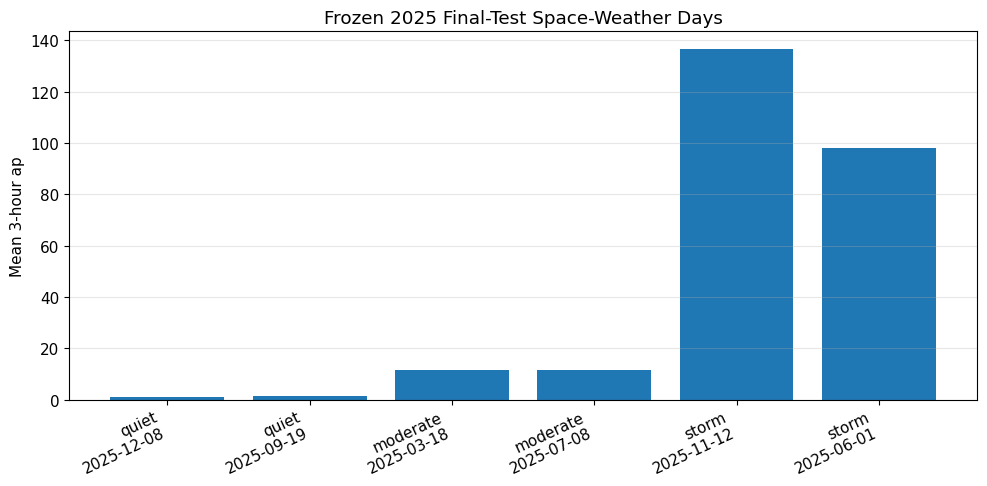

In [ ]:
plt.figure(figsize=(10, 5))
x = np.arange(len(test_weather_table))
plt.bar(x, test_weather_table["mean_3h_ap"])
plt.xticks(
    x,
    [f"{a}\n{b}" for a, b in zip(
        test_weather_table["weather_class"],
        test_weather_table["date"]
    )],
    rotation=25, ha="right"
)
plt.ylabel("Mean 3-hour ap")
plt.title("Frozen 2025 Final-Test Space-Weather Days")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "FINAL_2025_weather_selection.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
MU_EARTH = 398600.4418
R_EARTH = 6378.1363
J2 = 1.08262668e-3
OMEGA_EARTH = np.array([0.0, 0.0, 7.2921159e-5])

DYN_DT = float(manifest["dynamics_dt_seconds"])
DURATION_HOURS = int(manifest["duration_hours"])
N_STEPS = int(DURATION_HOURS * 3600 / DYN_DT) + 1

DENSITY_STEP_MIN = int(manifest["density_step_minutes"])
DENSITY_STEP_SECONDS = DENSITY_STEP_MIN * 60.0

ML_SAMPLE_MIN = int(manifest["ml_sample_minutes"])
ML_SAMPLE_STEPS = int(ML_SAMPLE_MIN * 60.0 / DYN_DT)
ML_SAMPLE_INDICES = np.arange(0, N_STEPS, ML_SAMPLE_STEPS, dtype=int)

SIGMA_A = float(manifest["sigma_a_km_s2"])
CD = float(manifest["drag_coefficient"])
AREA_TO_MASS = float(manifest["area_to_mass_m2_kg"])
R_STD = 0.5
OBS_SCHEDULES = manifest["observation_schedules"]

assert set(OBS_SCHEDULES) == {"nominal_10min", "nominal_20min", "gap_4h"}
print("🔒 Frozen configuration restored.")

🔒 Frozen configuration restored.


In [ ]:
def sgp4_state_at_offset(sat, dt_seconds):
    total = sat.jdsatepoch + sat.jdsatepochF + float(dt_seconds) / 86400.0
    jd = math.floor(total)
    fr = total - jd
    err, r, v = sat.sgp4(jd, fr)
    if err != 0:
        raise RuntimeError(f"SGP4 error {err}: {SGP4_ERRORS.get(err, 'unknown')}")
    return np.asarray(r, float), np.asarray(v, float)

def sgp4_series(sat, step_seconds, hours=24):
    n = int(hours * 3600 / step_seconds) + 1
    states = np.zeros((n, 6))
    for k in range(n):
        r, v = sgp4_state_at_offset(sat, k * step_seconds)
        states[k] = np.r_[r, v]
    return states

def teme_track_to_geodetic(sat, states, step_seconds):
    offsets = np.arange(len(states)) * step_seconds
    obstime = (
        Time(sat.jdsatepoch + sat.jdsatepochF, format="jd", scale="utc")
        + TimeDelta(offsets * u.s)
    )
    rep = CartesianRepresentation(
        x=states[:, 0] * u.km,
        y=states[:, 1] * u.km,
        z=states[:, 2] * u.km,
    )
    teme = TEME(rep, obstime=obstime)
    itrs = teme.transform_to(ITRS(obstime=obstime))
    xyz = itrs.cartesian
    loc = EarthLocation.from_geocentric(xyz.x, xyz.y, xyz.z)
    return {
        "lon_deg": loc.lon.to_value(u.deg),
        "lat_deg": loc.lat.to_value(u.deg),
        "alt_km": loc.height.to_value(u.km),
    }

flythrough_geometry = {}
for _, row in TEST_OBJECTS.iterrows():
    norad = int(row["NORAD_CAT_ID"])
    sat = satrec_by_norad[norad]
    track = sgp4_series(sat, DENSITY_STEP_SECONDS, hours=DURATION_HOURS)
    flythrough_geometry[norad] = {
        "track": track,
        "geo": teme_track_to_geodetic(sat, track, DENSITY_STEP_SECONDS),
        "time_s": np.arange(len(track)) * DENSITY_STEP_SECONDS,
    }

def build_density_profile(row, day):
    norad = int(row["NORAD_CAT_ID"])
    g = flythrough_geometry[norad]
    n = len(g["time_s"])
    start = np.datetime64(pd.Timestamp(day).date(), "m")
    dates = start + (np.arange(n) * DENSITY_STEP_MIN).astype("timedelta64[m]")
    f107, f107a, aps = get_f107_ap(dates)
    f107 = np.asarray(f107, float)
    f107a = np.asarray(f107a, float)
    aps = np.asarray(aps, float)
    geo = g["geo"]
    out = pymsis.calculate(
        dates,
        geo["lon_deg"],
        geo["lat_deg"],
        geo["alt_km"],
        f107s=f107,
        f107as=f107a,
        aps=aps,
        geomagnetic_activity=-1,
        version=0,
    )
    rho = np.asarray(out[..., pymsis.Variable.MASS_DENSITY]).squeeze().astype(float)
    if len(rho) != n or not np.all(np.isfinite(rho)) or np.any(rho <= 0):
        raise RuntimeError("Invalid MSIS density.")
    return {
        "time_s": g["time_s"].copy(),
        "rho_kg_m3": rho,
        "f107": f107,
        "current_ap": aps[:, 1].copy(),
    }

print("✅ Orbit + real-atmosphere helpers ready.")

✅ Orbit + real-atmosphere helpers ready.


In [ ]:
def accel_two_body_j2(r):
    r = np.asarray(r, float)
    x, y, z = r
    r2 = np.dot(r, r)
    rn = np.sqrt(r2)
    a2 = -MU_EARTH * r / rn**3
    common = 5.0 * z*z / r2
    factor = 1.5 * J2 * MU_EARTH * R_EARTH**2 / rn**5
    aj2 = factor * np.array([
        x * (common - 1.0),
        y * (common - 1.0),
        z * (common - 3.0),
    ])
    return a2 + aj2

def nominal_derivative(x):
    return np.r_[x[3:], accel_two_body_j2(x[:3])]

def rk4_nominal_step(x, dt):
    k1 = nominal_derivative(x)
    k2 = nominal_derivative(x + 0.5 * dt * k1)
    k3 = nominal_derivative(x + 0.5 * dt * k2)
    k4 = nominal_derivative(x + dt * k3)
    return x + dt / 6.0 * (k1 + 2*k2 + 2*k3 + k4)

def physical_drag_acceleration(r, v, rho):
    vatm = np.cross(OMEGA_EARTH, r)
    vrel = v - vatm
    speed = np.linalg.norm(vrel)
    vhat = vrel / (speed + 1e-15)
    accel_m_s2 = 0.5 * CD * AREA_TO_MASS * rho * (speed * 1000.0)**2
    return -(accel_m_s2 / 1000.0) * vhat

def truth_derivative(x, t, profile):
    rho = float(np.interp(t, profile["time_s"], profile["rho_kg_m3"]))
    return np.r_[x[3:], accel_two_body_j2(x[:3]) + physical_drag_acceleration(x[:3], x[3:], rho)]

def rk4_truth_step(x, t, dt, profile):
    k1 = truth_derivative(x, t, profile)
    k2 = truth_derivative(x + 0.5*dt*k1, t + 0.5*dt, profile)
    k3 = truth_derivative(x + 0.5*dt*k2, t + 0.5*dt, profile)
    k4 = truth_derivative(x + dt*k3, t + dt, profile)
    return x + dt/6.0 * (k1 + 2*k2 + 2*k3 + k4)

def propagate_truth(x0, profile):
    states = np.zeros((N_STEPS, 6))
    states[0] = x0
    for k in range(1, N_STEPS):
        states[k] = rk4_truth_step(states[k-1], (k-1)*DYN_DT, DYN_DT, profile)
        if np.linalg.norm(states[k, :3]) - R_EARTH < 120:
            states[k+1:] = np.nan
            break
    return states

print("✅ Physical truth dynamics ready.")

✅ Physical truth dynamics ready.


In [ ]:
def constant_acceleration_Q(dt, sigma_a):
    I3 = np.eye(3)
    return sigma_a**2 * np.block([
        [0.25*dt**4*I3, 0.5*dt**3*I3],
        [0.5*dt**3*I3, dt**2*I3],
    ])

def numerical_transition_jacobian(x, dt, eps_pos=1e-3, eps_vel=1e-6):
    f0 = rk4_nominal_step(x, dt)
    eps = np.array([eps_pos]*3 + [eps_vel]*3)
    F = np.zeros((6, 6))
    for i in range(6):
        xp = x.copy()
        xp[i] += eps[i]
        F[:, i] = (rk4_nominal_step(xp, dt) - f0) / eps[i]
    return F

class CartesianOrbitEKF:
    def __init__(self, dt, r_std, sigma_a):
        self.dt = float(dt)
        self.R = np.eye(3) * r_std**2
        self.H = np.eye(3, 6)
        self.Q = constant_acceleration_Q(self.dt, sigma_a)

    def run(self, x0, P0, obs_times, observations):
        obs = {int(k): np.asarray(z, float) for k, z in zip(obs_times, observations)}
        x = np.asarray(x0, float).copy()
        P = np.asarray(P0, float).copy()
        est = np.zeros((N_STEPS, 6))
        cov = np.zeros((N_STEPS, 6, 6))
        innov = np.full((N_STEPS, 3), np.nan)
        nis = np.full(N_STEPS, np.nan)

        def update(x, P, z):
            y = z - self.H @ x
            S = self.H @ P @ self.H.T + self.R
            K = np.linalg.solve(S, (P @ self.H.T).T).T
            xn = x + K @ y
            I = np.eye(6)
            KH = K @ self.H
            Pn = (I-KH) @ P @ (I-KH).T + K @ self.R @ K.T
            Pn = 0.5 * (Pn + Pn.T)
            n = float(y.T @ np.linalg.solve(S, y))
            return xn, Pn, y, n

        if 0 in obs:
            x, P, innov[0], nis[0] = update(x, P, obs[0])
        est[0], cov[0] = x, P

        for k in range(1, N_STEPS):
            F = numerical_transition_jacobian(x, self.dt)
            x = rk4_nominal_step(x, self.dt)
            P = F @ P @ F.T + self.Q
            P = 0.5 * (P + P.T)
            if k in obs:
                x, P, innov[k], nis[k] = update(x, P, obs[k])
            est[k], cov[k] = x, P

        return {"estimates": est, "covariances": cov, "innovations": innov, "nis": nis}

P0 = np.diag([2.0**2]*3 + [0.002**2]*3)

def build_observation_indices(schedule):
    step = int(round(schedule["cadence_min"] * 60.0 / DYN_DT))
    idx = np.arange(0, N_STEPS, step, dtype=int)
    t = idx * DYN_DT / 3600.0
    keep = np.ones(len(idx), dtype=bool)
    for start, end in schedule["outages_hr"]:
        keep &= ~((t >= start) & (t < end))
    return idx[keep]

print("✅ Frozen EKF ready.")

✅ Frozen EKF ready.


In [ ]:
def rtn_basis(state):
    r = np.asarray(state[:3], float)
    v = np.asarray(state[3:], float)
    Rhat = r / (np.linalg.norm(r) + 1e-15)
    h = np.cross(r, v)
    Nhat = h / (np.linalg.norm(h) + 1e-15)
    That = np.cross(Nhat, Rhat)
    return np.column_stack([Rhat, That, Nhat])

def eci_to_rtn(vec, state):
    return rtn_basis(state).T @ np.asarray(vec, float)

def rtn_to_eci(vec, state):
    return rtn_basis(state) @ np.asarray(vec, float)

def interp_profile(profile, key, t):
    return np.interp(t, profile["time_s"], profile[key])

def scenario_seed(norad, day):
    d = int(pd.Timestamp(day).strftime("%Y%m%d"))
    return int((int(norad) * 1000003 + d) % (2**32 - 1))

def make_truth_case(row, day, weather_class):
    norad = int(row["NORAD_CAT_ID"])
    sat = satrec_by_norad[norad]
    r0, v0 = sgp4_state_at_offset(sat, 0.0)
    x0 = np.r_[r0, v0]
    density = build_density_profile(row, day)
    truth = propagate_truth(x0, density)
    if not np.all(np.isfinite(truth)):
        return None
    return {
        "row": row.to_dict(),
        "norad": norad,
        "day": str(pd.Timestamp(day).date()),
        "weather_class": weather_class,
        "x0": x0,
        "truth": truth,
        "sgp4": sgp4_series(sat, DYN_DT, hours=DURATION_HOURS),
        "density": density,
    }

def make_filter_scenario(truth_case, schedule_name):
    schedule = OBS_SCHEDULES[schedule_name]
    truth = truth_case["truth"]
    base = scenario_seed(truth_case["norad"], truth_case["day"])
    noise = np.random.default_rng(base + 111).normal(0.0, R_STD, size=(N_STEPS, 3))
    rng = np.random.default_rng(base + 222)
    x0_est = truth_case["x0"].copy()
    x0_est[:3] += rng.normal(0.0, 2.0, 3)
    x0_est[3:] += rng.normal(0.0, 0.002, 3)
    obs_idx = build_observation_indices(schedule)
    observations = truth[obs_idx, :3] + noise[obs_idx]
    filt = CartesianOrbitEKF(DYN_DT, R_STD, SIGMA_A).run(
        x0_est, P0.copy(), obs_idx, observations
    )
    return {
        "schedule_name": schedule_name,
        "schedule": schedule,
        "obs_indices": obs_idx,
        "filter": filt,
        "truth_case": truth_case,
    }

def build_ml_sequence(scenario):
    filt = scenario["filter"]
    tc = scenario["truth_case"]
    truth = tc["truth"]
    est = filt["estimates"]
    obs_set = set(scenario["obs_indices"].tolist())

    features = np.zeros((N_STEPS, len(FEATURE_NAMES)))
    targets = np.zeros((N_STEPS, 3))
    last_obs = -1
    last_nis = 0.0
    last_innovation = np.zeros(3)

    for k in range(N_STEPS):
        if k in obs_set:
            last_obs = k
            if np.isfinite(filt["nis"][k]):
                last_nis = float(filt["nis"][k])
            if np.all(np.isfinite(filt["innovations"][k])):
                last_innovation = filt["innovations"][k].copy()

        gap_steps = k - last_obs if last_obs >= 0 else k
        t = k * DYN_DT
        rho = float(interp_profile(tc["density"], "rho_kg_m3", t))
        f107 = float(interp_profile(tc["density"], "f107", t))
        ap = float(interp_profile(tc["density"], "current_ap", t))

        irtn = eci_to_rtn(last_innovation, est[k])
        rrtn = eci_to_rtn(truth[k, :3] - est[k, :3], est[k])

        features[k] = [
            k / max(N_STEPS - 1, 1),
            gap_steps * DYN_DT / 60.0,
            scenario["schedule"]["cadence_min"],
            np.clip(last_nis, 0.0, 50.0) / 10.0,
            (f107 - 100.0) / 100.0,
            ap / 50.0,
            np.log10(max(rho, 1e-20)),
            (np.linalg.norm(est[k, :3]) - R_EARTH) / 1000.0,
            np.linalg.norm(est[k, 3:]) / 8.0,
            irtn[0] / R_STD,
            irtn[1] / R_STD,
            irtn[2] / R_STD,
        ]
        targets[k] = rrtn

    idx = ML_SAMPLE_INDICES
    return {
        "features": features[idx],
        "targets_rtn": targets[idx],
        "estimate_sampled": est[idx],
        "truth_sampled": truth[idx],
        "sgp4_sampled": tc["sgp4"][idx],
        "sample_indices": idx.copy(),
        "metadata": {
            "name": tc["row"]["OBJECT_NAME"],
            "norad": tc["norad"],
            "shell": tc["row"]["SHELL"],
            "approx_alt_km": tc["row"]["APPROX_ALT_KM"],
            "day": tc["day"],
            "weather_class": tc["weather_class"],
            "schedule": scenario["schedule_name"],
        },
    }

print("✅ Exact frozen feature pipeline ready.")

✅ Exact frozen feature pipeline ready.


# 4 — Generate the untouched final-test population

This is the main compute stage. It should produce 108 scenarios unless a physical trajectory falls below 120 km.

In [ ]:
DAY_CASES = [
    (cls, pd.Timestamp(day))
    for cls, days in TEST_WEATHER_DAYS.items()
    for day in days
]

final_sequences = []
skipped = []
total_truth = len(TEST_OBJECTS) * len(DAY_CASES)
counter = 0

for _, row in TEST_OBJECTS.iterrows():
    for weather_class, day in DAY_CASES:
        counter += 1
        print(
            f"[FINAL] truth {counter}/{total_truth} | "
            f"{row['OBJECT_NAME']} | {weather_class} | {day.date()}"
        )
        tc = make_truth_case(row, day, weather_class)
        if tc is None:
            skipped.append({
                "name": row["OBJECT_NAME"],
                "norad": int(row["NORAD_CAT_ID"]),
                "weather_class": weather_class,
                "day": str(day.date()),
                "reason": "trajectory_below_120km",
            })
            print("   ⚠️ skipped trajectory")
            continue
        for schedule_name in OBS_SCHEDULES:
            final_sequences.append(
                build_ml_sequence(
                    make_filter_scenario(tc, schedule_name)
                )
            )

pd.DataFrame(skipped).to_csv(DATA / "FINAL_skipped_truth_cases.csv", index=False)

print("\n✅ Final scenario generation complete")
print("sequences:", len(final_sequences))
print("skipped physical truth cases:", len(skipped))

[FINAL] truth 1/36 | STARLINK-1676 | quiet | 2025-12-08
[FINAL] truth 2/36 | STARLINK-1676 | quiet | 2025-09-19
[FINAL] truth 3/36 | STARLINK-1676 | moderate | 2025-03-18
[FINAL] truth 4/36 | STARLINK-1676 | moderate | 2025-07-08
[FINAL] truth 5/36 | STARLINK-1676 | storm | 2025-11-12
[FINAL] truth 6/36 | STARLINK-1676 | storm | 2025-06-01
[FINAL] truth 7/36 | STARLINK-32955 | quiet | 2025-12-08
[FINAL] truth 8/36 | STARLINK-32955 | quiet | 2025-09-19
[FINAL] truth 9/36 | STARLINK-32955 | moderate | 2025-03-18
[FINAL] truth 10/36 | STARLINK-32955 | moderate | 2025-07-08
[FINAL] truth 11/36 | STARLINK-32955 | storm | 2025-11-12
[FINAL] truth 12/36 | STARLINK-32955 | storm | 2025-06-01
[FINAL] truth 13/36 | STARLINK-11155 [DTC] | quiet | 2025-12-08
[FINAL] truth 14/36 | STARLINK-11155 [DTC] | quiet | 2025-09-19
[FINAL] truth 15/36 | STARLINK-11155 [DTC] | moderate | 2025-03-18
[FINAL] truth 16/36 | STARLINK-11155 [DTC] | moderate | 2025-07-08
[FINAL] truth 17/36 | STARLINK-11155 [DTC] | 

In [ ]:
def make_windows(features):
    return np.asarray(
        [features[t-SEQ_LEN:t] for t in range(SEQ_LEN, len(features))],
        dtype=np.float32,
    )

def scale_X(X):
    shape = X.shape
    return (
        feature_scaler.transform(X.reshape(-1, N_FEATURES))
        .reshape(shape)
        .astype(np.float32)
    )

def predict_rtn(sequence):
    X = scale_X(make_windows(sequence["features"]))
    with torch.no_grad():
        ps = model(torch.tensor(X, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    return target_scaler.inverse_transform(ps)

def metric_dict(pos, truth, times, gap=False):
    err = np.linalg.norm(pos - truth, axis=1)
    d = {
        "rmse": float(np.sqrt(np.mean(err**2))),
        "p95": float(np.percentile(err, 95)),
        "max": float(err.max()),
        "gap_rmse": np.nan,
    }
    if gap:
        m = (times >= 10.0) & (times < 14.0)
        d["gap_rmse"] = float(np.sqrt(np.mean(err[m]**2)))
    return d, err

final_rows = []
error_cache = {}

for i, seq in enumerate(final_sequences, start=1):
    pred = predict_rtn(seq)
    s = SEQ_LEN
    est = seq["estimate_sampled"][s:]
    truth = seq["truth_sampled"][s:]
    sgp4 = seq["sgp4_sampled"][s:]
    idx = seq["sample_indices"][s:]
    times = idx * DYN_DT / 3600.0

    corrected = est[:, :3].copy()
    for j in range(len(corrected)):
        corrected[j] += rtn_to_eci(pred[j], est[j])

    is_gap = seq["metadata"]["schedule"] == "gap_4h"
    ms, es = metric_dict(sgp4[:, :3], truth[:, :3], times, gap=is_gap)
    me, ee = metric_dict(est[:, :3], truth[:, :3], times, gap=is_gap)
    mh, eh = metric_dict(corrected, truth[:, :3], times, gap=is_gap)

    meta = seq["metadata"]
    final_rows.append({
        **meta,
        "rmse_sgp4_km": ms["rmse"],
        "rmse_ekf_km": me["rmse"],
        "rmse_hybrid_km": mh["rmse"],
        "p95_sgp4_km": ms["p95"],
        "p95_ekf_km": me["p95"],
        "p95_hybrid_km": mh["p95"],
        "max_sgp4_km": ms["max"],
        "max_ekf_km": me["max"],
        "max_hybrid_km": mh["max"],
        "outage_rmse_sgp4_km": ms["gap_rmse"],
        "outage_rmse_ekf_km": me["gap_rmse"],
        "outage_rmse_hybrid_km": mh["gap_rmse"],
        "hybrid_gain_km": me["rmse"] - mh["rmse"],
        "hybrid_improvement_pct": 100.0 * (1.0 - mh["rmse"] / me["rmse"]),
        "hybrid_better": mh["rmse"] < me["rmse"],
    })

    error_cache[(int(meta["norad"]), str(meta["day"]), str(meta["schedule"]))] = {
        "times": times,
        "sgp4": es,
        "ekf": ee,
        "hybrid": eh,
        "metadata": meta,
    }

    if i % 18 == 0 or i == len(final_sequences):
        print(f"evaluated {i}/{len(final_sequences)}")

final_results = pd.DataFrame(final_rows)
final_results.to_csv(OUT / "FINAL_scenario_results.csv", index=False)

print("✅ Frozen final inference complete.")

evaluated 18/108
evaluated 36/108
evaluated 54/108
evaluated 72/108
evaluated 90/108
evaluated 108/108
✅ Frozen final inference complete.


# 5 — FINAL held-out results

The first result is the descriptive mean across all final scenarios. The next cell reports the primary object × weather-day paired confidence interval.

In [ ]:
mean_sgp4 = float(final_results["rmse_sgp4_km"].mean())
mean_ekf = float(final_results["rmse_ekf_km"].mean())
mean_hybrid = float(final_results["rmse_hybrid_km"].mean())
overall_reduction = 100.0 * (1.0 - mean_hybrid / mean_ekf)
scenario_win_rate = float(final_results["hybrid_better"].mean())

print("=" * 96)
print("FINAL HELD-OUT TEST — UNSEEN TEST STARLINKS + UNSEEN 2025 REAL WEATHER")
print("=" * 96)
print(f"Scenarios            : {len(final_results)}")
print(f"SGP4 mean RMSE       : {mean_sgp4:.3f} km")
print(f"Tuned EKF mean RMSE  : {mean_ekf:.3f} km")
print(f"Hybrid mean RMSE     : {mean_hybrid:.3f} km")
print()
print(f"Hybrid RMSE reduction vs EKF : {overall_reduction:.2f}%")
print(f"Scenario win rate            : {scenario_win_rate:.1%}")
print("=" * 96)

FINAL HELD-OUT TEST — UNSEEN TEST STARLINKS + UNSEEN 2025 REAL WEATHER
Scenarios            : 108
SGP4 mean RMSE       : 84.145 km
Tuned EKF mean RMSE  : 1.971 km
Hybrid mean RMSE     : 0.559 km

Hybrid RMSE reduction vs EKF : 71.63%
Scenario win rate            : 74.1%


In [ ]:
cluster_df = (
    final_results
    .groupby(["norad", "name", "shell", "day", "weather_class"], as_index=False)
    .agg(
        ekf_mean_km=("rmse_ekf_km", "mean"),
        hybrid_mean_km=("rmse_hybrid_km", "mean"),
        gain_mean_km=("hybrid_gain_km", "mean"),
        schedule_win_fraction=("hybrid_better", "mean"),
    )
)

g = cluster_df["gain_mean_km"].to_numpy()
n_clusters = len(g)
gmean = float(g.mean())
gsd = float(g.std(ddof=1))
half = float(student_t.ppf(0.975, n_clusters - 1) * gsd / np.sqrt(n_clusters))
ci_low, ci_high = gmean - half, gmean + half
tt = ttest_1samp(g, popmean=0.0)

try:
    wx = wilcoxon(g, alternative="greater", zero_method="wilcox")
    wx_p = float(wx.pvalue)
except Exception:
    wx_p = np.nan

cluster_df.to_csv(OUT / "FINAL_object_weather_cluster_results.csv", index=False)

print("PRIMARY PAIRED ANALYSIS — OBJECT × WEATHER-DAY CLUSTERS")
print(f"clusters                   : {n_clusters}")
print(f"mean paired gain           : {gmean:.3f} km")
print(f"95% CI                     : [{ci_low:.3f}, {ci_high:.3f}] km")
print(f"two-sided t-test p         : {float(tt.pvalue):.4g}")
print(f"one-sided Wilcoxon p       : {wx_p:.4g}")
print(f"positive cluster gains     : {np.mean(g > 0):.1%}")

PRIMARY PAIRED ANALYSIS — OBJECT × WEATHER-DAY CLUSTERS
clusters                   : 36
mean paired gain           : 1.412 km
95% CI                     : [0.675, 2.149] km
two-sided t-test p         : 0.0004287
one-sided Wilcoxon p       : 1.062e-05
positive cluster gains     : 75.0%


In [ ]:
object_df = (
    final_results
    .groupby(["norad", "name", "shell"], as_index=False)
    .agg(
        ekf_mean_km=("rmse_ekf_km", "mean"),
        hybrid_mean_km=("rmse_hybrid_km", "mean"),
        gain_mean_km=("hybrid_gain_km", "mean"),
        scenario_win_rate=("hybrid_better", "mean"),
    )
)
object_df["improvement_pct"] = 100.0 * (
    1.0 - object_df["hybrid_mean_km"] / object_df["ekf_mean_km"]
)
object_df.to_csv(OUT / "FINAL_object_level_results.csv", index=False)

loo_rows = []
for norad in object_df["norad"]:
    x = final_results[final_results["norad"] != norad]
    e = float(x["rmse_ekf_km"].mean())
    h = float(x["rmse_hybrid_km"].mean())
    loo_rows.append({
        "excluded_norad": int(norad),
        "ekf_mean_km": e,
        "hybrid_mean_km": h,
        "improvement_pct": 100.0 * (1.0 - h/e),
    })
loo_df = pd.DataFrame(loo_rows)
loo_df.to_csv(OUT / "FINAL_leave_one_object_out.csv", index=False)

def grouped(col):
    x = (
        final_results.groupby(col)
        .agg(
            n=("rmse_ekf_km", "size"),
            sgp4_mean_km=("rmse_sgp4_km", "mean"),
            ekf_mean_km=("rmse_ekf_km", "mean"),
            hybrid_mean_km=("rmse_hybrid_km", "mean"),
            gain_mean_km=("hybrid_gain_km", "mean"),
            win_rate=("hybrid_better", "mean"),
        )
        .reset_index()
    )
    x["ratio_improvement_pct"] = 100.0 * (
        1.0 - x["hybrid_mean_km"] / x["ekf_mean_km"]
    )
    return x

by_weather = grouped("weather_class")
by_schedule = grouped("schedule")
by_shell = grouped("shell")

by_weather.to_csv(OUT / "FINAL_by_weather.csv", index=False)
by_schedule.to_csv(OUT / "FINAL_by_schedule.csv", index=False)
by_shell.to_csv(OUT / "FINAL_by_shell.csv", index=False)

print("\nOBJECT LEVEL")
display(object_df.round(4))
print(f"objects with positive mean gain: {np.mean(object_df['gain_mean_km'] > 0):.1%}")
print(
    "leave-one-object-out improvement range: "
    f"{loo_df['improvement_pct'].min():.2f}% to {loo_df['improvement_pct'].max():.2f}%"
)

print("\nBY WEATHER")
display(by_weather.round(4))
print("\nBY OBSERVATION REGIME")
display(by_schedule.round(4))
print("\nBY SHELL")
display(by_shell.round(4))


OBJECT LEVEL


,norad,name,shell,ekf_mean_km,hybrid_mean_km,gain_mean_km,scenario_win_rate,improvement_pct
0,46556,STARLINK-1676,53deg,6.9494,1.2198,5.7297,1.0000,82.4481
1,56776,STARLINK-6274,70deg,0.3176,0.3242,-0.0066,0.3333,-2.0700
2,60046,STARLINK-11155 [DTC],53deg,1.0382,0.4580,0.5803,1.0000,55.8907
3,61976,STARLINK-32611,43deg,0.3264,0.3074,0.0191,0.7222,5.8392
4,63117,STARLINK-32955,43deg,2.8890,0.7345,2.1544,1.0000,74.5743
5,64157,STARLINK-34343,97deg,0.3077,0.3114,-0.0036,0.3889,-1.1751


objects with positive mean gain: 66.7%
leave-one-object-out improvement range: 56.23% to 73.67%

BY WEATHER


,weather_class,n,sgp4_mean_km,ekf_mean_km,hybrid_mean_km,gain_mean_km,win_rate,ratio_improvement_pct
0,moderate,36,79.0427,1.8395,0.5720,1.2675,0.6667,68.9046
1,quiet,36,74.2669,1.7652,0.4817,1.2835,0.8056,72.7117
2,storm,36,99.1241,2.3095,0.6239,1.6856,0.7500,72.9861



BY OBSERVATION REGIME


,schedule,n,sgp4_mean_km,ekf_mean_km,hybrid_mean_km,gain_mean_km,win_rate,ratio_improvement_pct
0,gap_4h,36,84.1446,3.2159,0.8611,2.3549,0.6944,73.2241
1,nominal_10min,36,84.1446,1.1025,0.3245,0.7780,0.7222,70.5692
2,nominal_20min,36,84.1446,1.5958,0.4920,1.1038,0.8056,69.1677



BY SHELL


,shell,n,sgp4_mean_km,ekf_mean_km,hybrid_mean_km,gain_mean_km,win_rate,ratio_improvement_pct
0,43deg,36,54.8869,1.6077,0.5210,1.0867,0.8611,67.5959
1,53deg,36,158.3857,3.9938,0.8389,3.1550,1.0000,78.9961
2,70deg,18,65.5088,0.3176,0.3242,-0.0066,0.3333,-2.0700
3,97deg,18,12.8134,0.3077,0.3114,-0.0036,0.3889,-1.1751


In [ ]:
tail_summary = pd.DataFrame([
    {
        "method": "SGP4",
        "mean_RMSE_km": final_results["rmse_sgp4_km"].mean(),
        "mean_P95_km": final_results["p95_sgp4_km"].mean(),
        "mean_max_error_km": final_results["max_sgp4_km"].mean(),
        "gap4h_outage_RMSE_km": final_results.loc[
            final_results["schedule"] == "gap_4h", "outage_rmse_sgp4_km"
        ].mean(),
    },
    {
        "method": "Tuned EKF",
        "mean_RMSE_km": final_results["rmse_ekf_km"].mean(),
        "mean_P95_km": final_results["p95_ekf_km"].mean(),
        "mean_max_error_km": final_results["max_ekf_km"].mean(),
        "gap4h_outage_RMSE_km": final_results.loc[
            final_results["schedule"] == "gap_4h", "outage_rmse_ekf_km"
        ].mean(),
    },
    {
        "method": "EKF + GRU",
        "mean_RMSE_km": final_results["rmse_hybrid_km"].mean(),
        "mean_P95_km": final_results["p95_hybrid_km"].mean(),
        "mean_max_error_km": final_results["max_hybrid_km"].mean(),
        "gap4h_outage_RMSE_km": final_results.loc[
            final_results["schedule"] == "gap_4h", "outage_rmse_hybrid_km"
        ].mean(),
    },
])
tail_summary.to_csv(OUT / "FINAL_tail_error_summary.csv", index=False)
display(tail_summary.round(4))

,method,mean_RMSE_km,mean_P95_km,mean_max_error_km,gap4h_outage_RMSE_km
0,SGP4,84.1446,166.5648,183.6422,46.7906
1,Tuned EKF,1.9714,4.0305,5.9737,7.1588
2,EKF + GRU,0.5592,1.0057,3.0314,1.5139


# 6 — Paper-ready figures

The representative time-series is predeclared by metadata: median-altitude TEST object, most active selected storm day, and the 4-hour blackout schedule. It is **not** selected because it looks best.

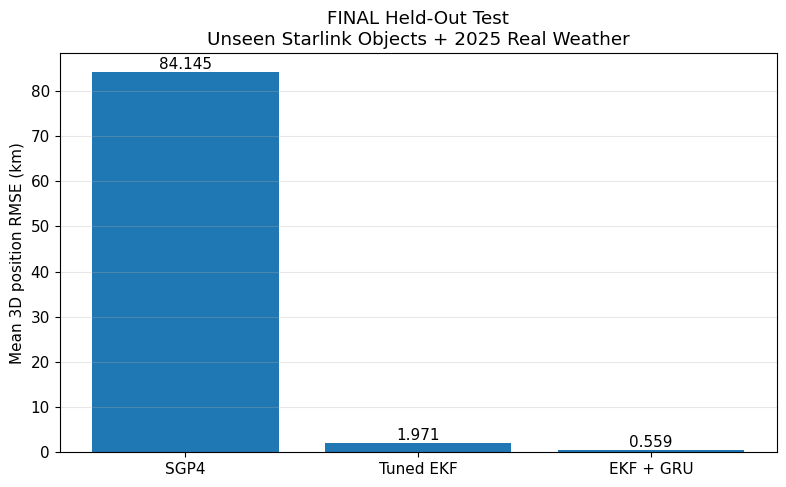

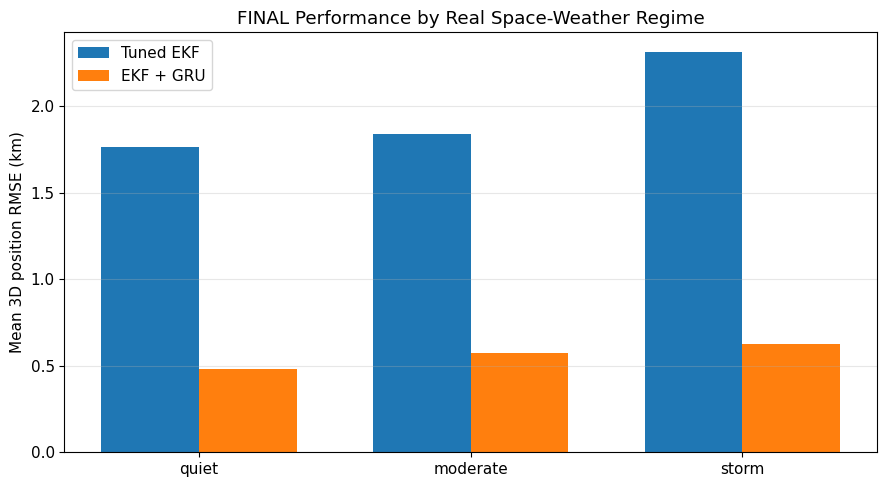

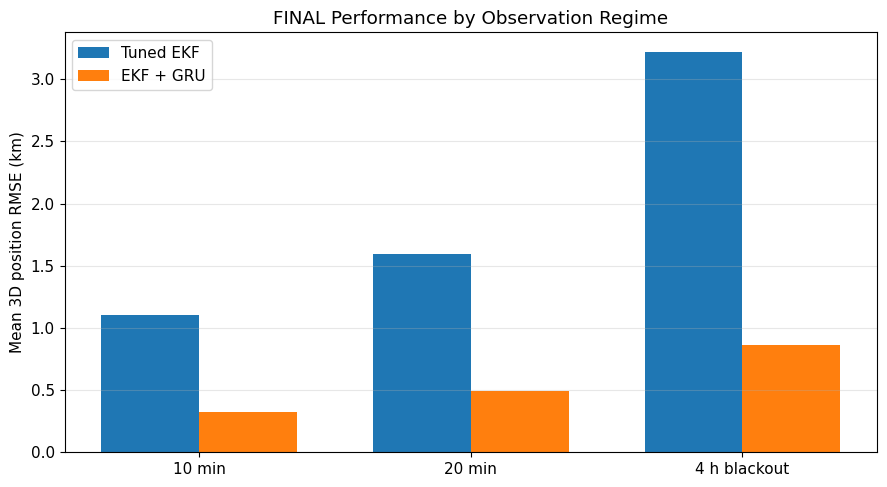

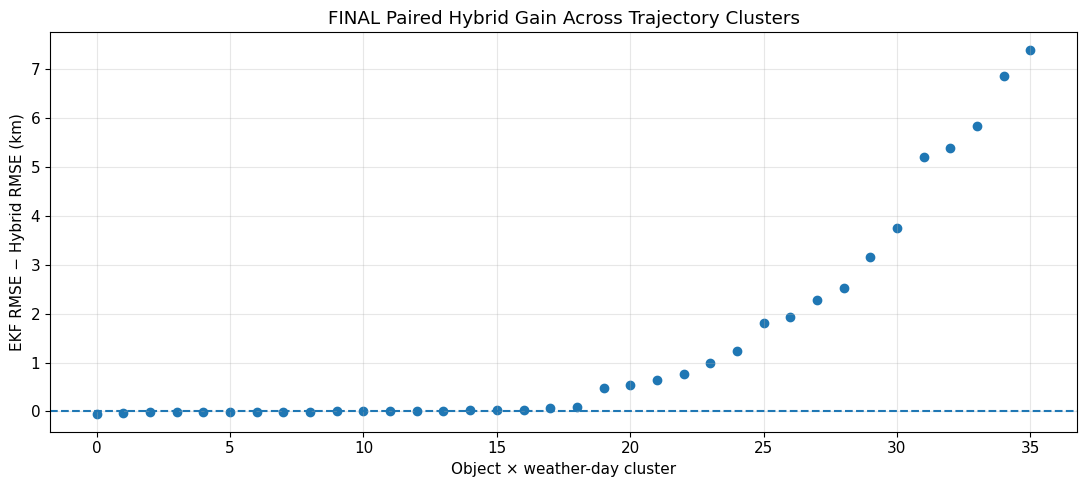

In [ ]:
# Mean RMSE
plt.figure(figsize=(8, 5))
labels = ["SGP4", "Tuned EKF", "EKF + GRU"]
vals = [mean_sgp4, mean_ekf, mean_hybrid]
bars = plt.bar(labels, vals)
plt.ylabel("Mean 3D position RMSE (km)")
plt.title("FINAL Held-Out Test\nUnseen Starlink Objects + 2025 Real Weather")
plt.grid(axis="y", alpha=0.3)
for b, v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, b.get_height(), f"{v:.3f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(OUT / "FINAL_mean_RMSE.png", dpi=200, bbox_inches="tight")
plt.show()

# Weather
order = ["quiet", "moderate", "storm"]
w = by_weather.set_index("weather_class").loc[order]
x = np.arange(3)
width = 0.36
plt.figure(figsize=(9, 5))
plt.bar(x-width/2, w["ekf_mean_km"], width, label="Tuned EKF")
plt.bar(x+width/2, w["hybrid_mean_km"], width, label="EKF + GRU")
plt.xticks(x, order)
plt.ylabel("Mean 3D position RMSE (km)")
plt.title("FINAL Performance by Real Space-Weather Regime")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "FINAL_by_weather.png", dpi=200, bbox_inches="tight")
plt.show()

# Observation regime
order_s = ["nominal_10min", "nominal_20min", "gap_4h"]
s = by_schedule.set_index("schedule").loc[order_s]
x = np.arange(3)
plt.figure(figsize=(9, 5))
plt.bar(x-width/2, s["ekf_mean_km"], width, label="Tuned EKF")
plt.bar(x+width/2, s["hybrid_mean_km"], width, label="EKF + GRU")
plt.xticks(x, ["10 min", "20 min", "4 h blackout"])
plt.ylabel("Mean 3D position RMSE (km)")
plt.title("FINAL Performance by Observation Regime")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "FINAL_by_observation_regime.png", dpi=200, bbox_inches="tight")
plt.show()

# Cluster gains
cg = cluster_df.sort_values("gain_mean_km").reset_index(drop=True)
plt.figure(figsize=(11, 5))
plt.scatter(np.arange(len(cg)), cg["gain_mean_km"])
plt.axhline(0.0, linestyle="--")
plt.xlabel("Object × weather-day cluster")
plt.ylabel("EKF RMSE − Hybrid RMSE (km)")
plt.title("FINAL Paired Hybrid Gain Across Trajectory Clusters")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "FINAL_cluster_paired_gains.png", dpi=200, bbox_inches="tight")
plt.show()

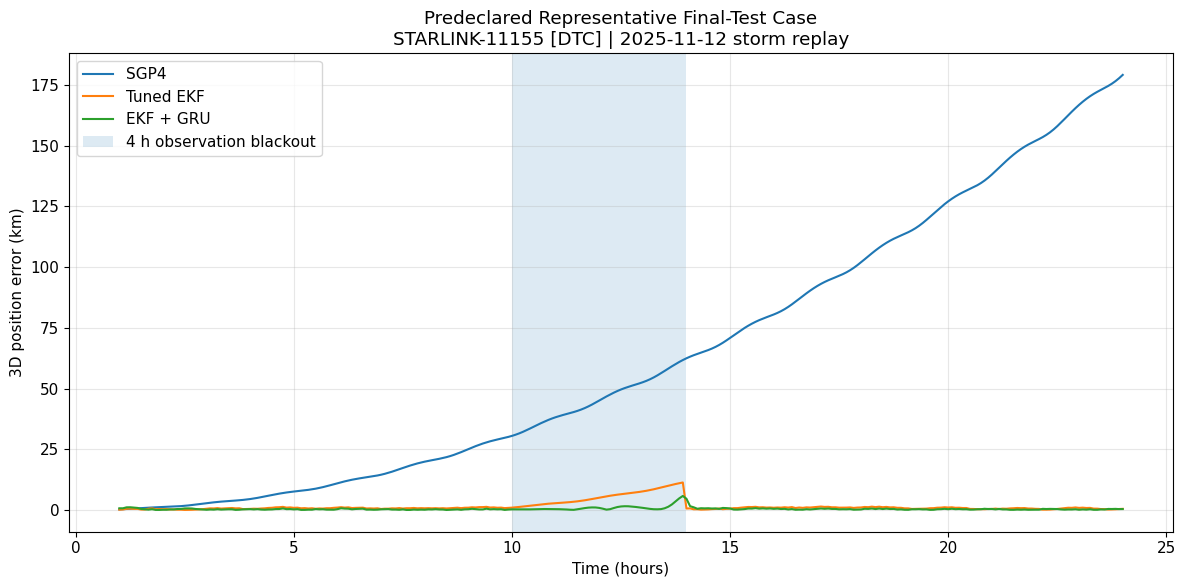

Representative object: STARLINK-11155 [DTC] | 359.8 km
Representative storm day: 2025-11-12


In [ ]:
median_alt = float(TEST_OBJECTS["APPROX_ALT_KM"].median())
rep_idx = (TEST_OBJECTS["APPROX_ALT_KM"] - median_alt).abs().idxmin()
rep_obj = TEST_OBJECTS.loc[rep_idx]
rep_norad = int(rep_obj["NORAD_CAT_ID"])

storm_rows = test_weather_table[test_weather_table["weather_class"] == "storm"]
rep_day = str(
    storm_rows.sort_values(
        ["mean_3h_ap", "max_3h_ap"], ascending=False
    ).iloc[0]["date"]
)

key = (rep_norad, rep_day, "gap_4h")
if key not in error_cache:
    raise RuntimeError("Predeclared representative case unavailable.")

rep = error_cache[key]
plt.figure(figsize=(12, 6))
plt.plot(rep["times"], rep["sgp4"], label="SGP4")
plt.plot(rep["times"], rep["ekf"], label="Tuned EKF")
plt.plot(rep["times"], rep["hybrid"], label="EKF + GRU")
plt.axvspan(10, 14, alpha=0.15, label="4 h observation blackout")
plt.xlabel("Time (hours)")
plt.ylabel("3D position error (km)")
plt.title(
    f"Predeclared Representative Final-Test Case\n"
    f"{rep_obj['OBJECT_NAME']} | {rep_day} storm replay"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "FINAL_representative_gap_timeseries.png", dpi=200, bbox_inches="tight")
plt.show()

print("Representative object:", rep_obj["OBJECT_NAME"], "|", f"{rep_obj['APPROX_ALT_KM']:.1f} km")
print("Representative storm day:", rep_day)

In [ ]:
summary = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "LOCKED_FINAL_TEST_COMPLETE",
    "source_week2a_bundle": ZIP_PATH.name,
    "verified_frozen_hashes": EXPECTED_HASHES,
    "n_test_objects": int(len(TEST_OBJECTS)),
    "n_test_weather_days": int(len(test_weather_table)),
    "n_final_scenarios": int(len(final_results)),
    "n_object_weather_clusters": int(n_clusters),
    "test_weather_days": {
        k: [str(pd.Timestamp(d).date()) for d in days]
        for k, days in TEST_WEATHER_DAYS.items()
    },
    "frozen_sigma_a_km_s2": SIGMA_A,
    "frozen_feature_names": FEATURE_NAMES,
    "frozen_seq_len": SEQ_LEN,
    "frozen_hidden_size": HIDDEN_SIZE,
    "frozen_dropout": DROPOUT,
    "mean_rmse_km": {
        "sgp4": mean_sgp4,
        "tuned_ekf": mean_ekf,
        "hybrid": mean_hybrid,
    },
    "hybrid_rmse_reduction_pct": overall_reduction,
    "scenario_win_rate": scenario_win_rate,
    "cluster_paired_gain_km": gmean,
    "cluster_paired_gain_ci95_km": [ci_low, ci_high],
    "cluster_ttest_p": float(tt.pvalue),
    "cluster_wilcoxon_one_sided_p": wx_p,
    "positive_cluster_fraction": float(np.mean(g > 0)),
    "positive_object_fraction": float(np.mean(object_df["gain_mean_km"] > 0)),
    "leave_one_object_out_improvement_range_pct": [
        float(loo_df["improvement_pct"].min()),
        float(loo_df["improvement_pct"].max()),
    ],
    "limitations": [
        "Historical weather replay is applied to frozen 2026 Starlink orbital geometries.",
        "Cd and area-to-mass ratio are representative rather than known for each spacecraft.",
        "Measurements are noisy Cartesian positions rather than raw radar/optical observations.",
        "NRLMSISE-00 density is evaluated along the nominal fly-through and interpolated into truth propagation.",
    ],
}

with open(ROOT / "FINAL_RESULTS_SUMMARY.json", "w") as f:
    json.dump(summary, f, indent=2)

print("🔒 FINAL_RESULTS_SUMMARY.json saved")
print("\nSaved output files:")
for p in sorted(OUT.glob("*")):
    print(" -", p.name)

🔒 FINAL_RESULTS_SUMMARY.json saved

Saved output files:
 - FINAL_2025_weather_selection.png
 - FINAL_by_observation_regime.png
 - FINAL_by_schedule.csv
 - FINAL_by_shell.csv
 - FINAL_by_weather.csv
 - FINAL_by_weather.png
 - FINAL_cluster_paired_gains.png
 - FINAL_leave_one_object_out.csv
 - FINAL_mean_RMSE.png
 - FINAL_object_level_results.csv
 - FINAL_object_weather_cluster_results.csv
 - FINAL_representative_gap_timeseries.png
 - FINAL_scenario_results.csv
 - FINAL_tail_error_summary.csv


# FINAL STOP

If the notebook reaches here, the held-out test has been completed.

**Do not modify and rerun the model because of the observed result.**

Download the final ZIP and the executed notebook, then send both back for independent inspection.

In [ ]:
DOWNLOAD_FINAL_BUNDLE = True

if DOWNLOAD_FINAL_BUNDLE:
    archive_base = "/content/IAC2026_FINAL_WEEK2B_RESULTS"
    shutil.make_archive(archive_base, "zip", ROOT)
    archive = archive_base + ".zip"
    print("🔒 Final archive created:", archive)
    from google.colab import files
    files.download(archive)
else:
    print("Set DOWNLOAD_FINAL_BUNDLE = True after the full run finishes, then run this cell once.")

🔒 Final archive created: /content/IAC2026_FINAL_WEEK2B_RESULTS.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>